In [95]:
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torchvision import models
from tqdm import tqdm

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
# Аугментация для тренировочных данных
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(), # рандомно инвертируем по горизонтали
    transforms.RandomRotation(15), # рандомно поворачиваем
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)), # рандомно усекаем
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # RGB
])

In [3]:
# Только нормализация (для тестовых данных)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
# Загрузка датасета
full_data = datasets.EuroSAT(root='./EuroSAT_data', transform=train_transform, download=True)

100%|██████████| 94.3M/94.3M [00:08<00:00, 11.3MB/s]


In [5]:
# Разделение на train/test (80/20)
train_size = int(0.8 * len(full_data))
test_size = len(full_data) - train_size
train_data, test_data = random_split(full_data, [train_size, test_size])

In [6]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [53]:
mean_tensor = torch.Tensor([0.485, 0.456, 0.406])

In [ ]:
example_loader = next(enumerate(train_loader))
example_loader = example_loader[1][0][0]

print('Src shape: ', example_loader.shape)
# Перетасовка каналов таким образом, чтобы их содержала самая глубокая размерность
print('Permute shape: ', example_loader.permute(1,2,0).shape) 

print(example_loader.permute(1,2,0) * mean_tensor + mean_tensor)

Src shape:  torch.Size([3, 64, 64])
Permute shape:  torch.Size([64, 64, 3])
tensor([[[-0.2266,  0.0466,  0.2112],
         [-0.2266,  0.0227,  0.2041],
         [-0.2349,  0.0067,  0.1970],
         ...,
         [-0.0272,  0.2223,  0.2890],
         [-0.0272,  0.2302,  0.3032],
         [-0.0355,  0.2143,  0.3103]],

        [[-0.2349,  0.0386,  0.2041],
         [-0.2515,  0.0227,  0.1900],
         [-0.2515, -0.0013,  0.1829],
         ...,
         [-0.0355,  0.2223,  0.3032],
         [-0.0355,  0.2143,  0.3103],
         [-0.0272,  0.2143,  0.3103]],

        [[-0.2515,  0.0147,  0.1970],
         [-0.2349,  0.0386,  0.2112],
         [-0.2183,  0.0307,  0.2112],
         ...,
         [-0.0189,  0.2223,  0.3173],
         [-0.0189,  0.2223,  0.3173],
         [-0.0272,  0.2143,  0.3103]],

        ...,

        [[-0.0355,  0.2143,  0.3103],
         [-0.0355,  0.2143,  0.3173],
         [-0.0355,  0.2143,  0.3103],
         ...,
         [-0.0189,  0.2223,  0.3173],
         [-0

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5421834..1.550804].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5421834..1.5757205].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5421834..0.61453724].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5421834..0.5225459].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5421834..1.0607792].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5421834..1.451138].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5421834

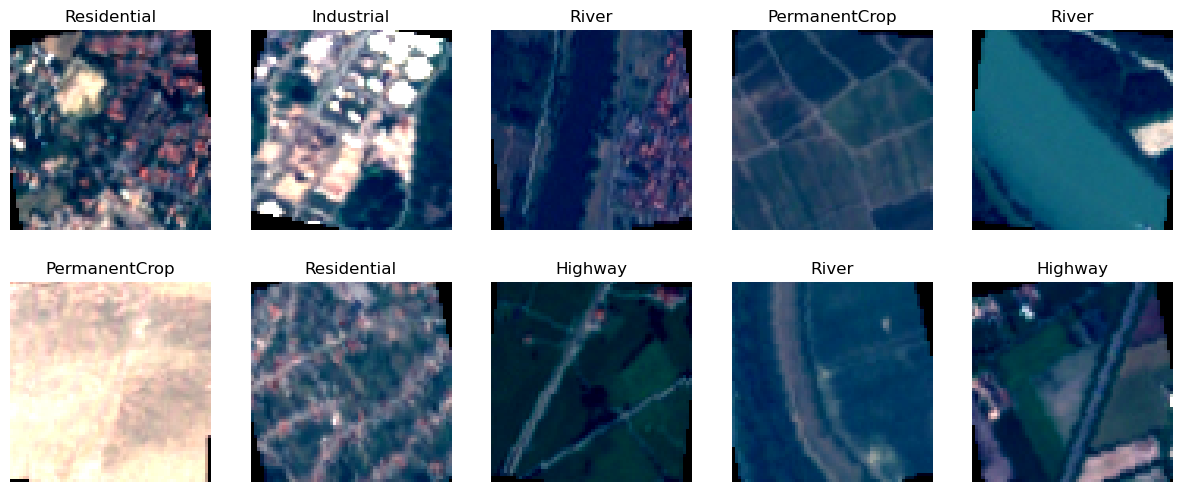

In [56]:
classes = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial',
           'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img, label = train_data[i]
    ax.imshow(img.permute(1,2,0) * mean_tensor + mean_tensor)  # Денормализация
    # ax.imshow(img.permute(1, 2, 0) * 0.5 + 0.5)  # Денормализация
    ax.set_title(classes[label])
    ax.axis('off')
plt.show();

1. Простая архитектура

In [92]:
class SimpleCNN(nn.Module):
    def __init__(self, debug=False):
        super().__init__()
        self.debug = debug
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)  # 3 канала (RGB) входящих, 16 каналов исходящих (глубина тензора)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Уменьшение размерности WхH в 2 раза
        self.flatten = nn.Flatten() # Аналог x.view(-1, 32 * 16 * 16)
        self.fc1 = nn.Linear(32 * 16 * 16, 256)  # 64x64 -> 32x32 -> 16x16
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        if self.debug:
            print('Input x: ', x.shape)

        x = F.relu(self.conv1(x))
        if self.debug:
            print('Conv1 x: ', x.shape)

        x = self.pool(x)
        if self.debug:
            print('Pool x: ', x.shape)

        x = F.relu(self.conv2(x))
        if self.debug:
            print('Conv2 x: ', x.shape)

        x = self.pool(x)
        if self.debug:
            print('Pool x: ', x.shape)

        # x = x.view(-1, 32 * 16 * 16)
        x = self.flatten(x)
        if self.debug:
            print('Flat x: ', x.shape)

        x = F.relu(self.fc1(x))
        if self.debug:
            print('FC1 x: ', x.shape)

        x = self.fc2(x)
        if self.debug:
            print('Output x: ', x.shape)
        return x

In [94]:
from torchsummary import summary

simple_model = SimpleCNN(debug=True)
print(simple_model)

example_batch = next(enumerate(train_loader))[1][0]
print('Batch example size: ', example_batch.shape)

print('Summary:')
example_x = example_batch[0]
summary(simple_model, example_x.shape, device='cpu')

# Приведение наблюдения к батчу через добавление размерности
# Оказалось лишним, так как в summary уже выполняется проход
# output = simple_model(torch.unsqueeze(example_x, 0))

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=8192, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)
Batch example size:  torch.Size([64, 3, 64, 64])
Summary:
Input x:  torch.Size([2, 3, 64, 64])
Conv1 x:  torch.Size([2, 16, 64, 64])
Pool x:  torch.Size([2, 16, 32, 32])
Conv2 x:  torch.Size([2, 32, 32, 32])
Pool x:  torch.Size([2, 32, 16, 16])
Flat x:  torch.Size([2, 8192])
FC1 x:  torch.Size([2, 256])
Output x:  torch.Size([2, 10])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             448
         MaxPool2d-2           [-1, 16, 32, 32]   

2. Расширенная CNN (с BatchNorm и Dropout)

In [9]:
class AdvancedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 8 * 8, 512)  # 64x64 -> 32x32 -> 16x16 -> 8x8
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 8 * 8)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

3. Transfer Learning (ResNet18)

In [10]:
class ResNet18(nn.Module):
    def __init__(self):
        super().__init__()
        self.base = models.resnet18(pretrained=True) # загружаем модель
        self.base.fc = nn.Linear(512, 10)  # Заменяем последний слой

    def forward(self, x):
        return self.base(x)

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
models_dict = {
    'SimpleCNN': SimpleCNN().to(device),
    'AdvancedCNN': AdvancedCNN().to(device),
    'ResNet18': ResNet18().to(device)
}

criterion = nn.CrossEntropyLoss()
optimizer_dict = {
    name: torch.optim.Adam(model.parameters(), lr=0.001)
    for name, model in models_dict.items()
}

d:\Apps\Anaconda3\envs\otus-ml\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Apps\Anaconda3\envs\otus-ml\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\MazurenkoEV/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:04<00:00, 9.98MB/s]


In [100]:
def train_model(model, optimizer, num_epochs=1): # для демонстрации укажем 1 эпоху
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}')

# Обучаем все модели
for name, model in tqdm(models_dict.items()):
    print(f"Training {name}...")
    train_model(model, optimizer_dict[name], num_epochs=3)

  0%|          | 0/3 [00:00<?, ?it/s]

Training SimpleCNN...
Epoch 1, Loss: 0.6225
Epoch 2, Loss: 0.5618


 33%|███▎      | 1/3 [00:30<01:00, 30.04s/it]

Epoch 3, Loss: 0.5011
Training AdvancedCNN...
Epoch 1, Loss: 0.7499
Epoch 2, Loss: 0.7150


 67%|██████▋   | 2/3 [01:02<00:31, 31.48s/it]

Epoch 3, Loss: 0.6406
Training ResNet18...
Epoch 1, Loss: 0.2301
Epoch 2, Loss: 0.2089


100%|██████████| 3/3 [01:39<00:00, 33.23s/it]

Epoch 3, Loss: 0.1882


In [101]:
def evaluate(model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

results = {name: evaluate(model) for name, model in tqdm(models_dict.items())}
print("Test Accuracy (%):")
for name, acc in results.items():
    print(f"{name}: {acc:.2f}%")

100%|██████████| 3/3 [00:08<00:00,  2.73s/it]

Test Accuracy (%):
SimpleCNN: 82.76%
AdvancedCNN: 79.26%
ResNet18: 94.70%


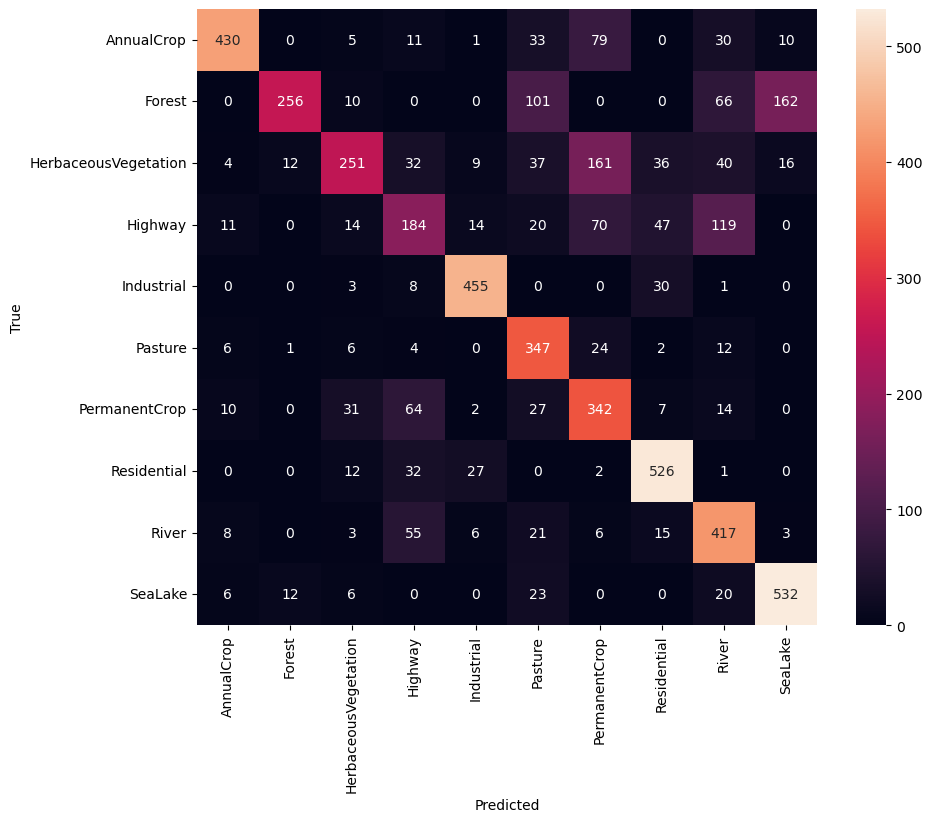

In [14]:
model = models_dict['AdvancedCNN']
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()